# H1V2 SIM 2 SIM
Squat using mujoco with help of tools developped in LAAS : https://github.com/Gepetto/h1v2-Isaac/tree/dev

## difficulties

mujoco q_pose differ from pinocchio q_pos (quaternion)
    - mujoco : q[0:3] = [w, x, y, z]
    - pinocchio : q[0:3] = [x, y, z, w]

extracted model from MJCF had also some differencies, so I had to modify root_joint name and reduce robot hight (Z)

others checks are made on this page, to be sure to have a good interface between mujoco and pinocchio.

In [1]:
import time
import numpy as np
import pinocchio as pin
from pinocchio.shortcuts import buildModelsFromMJCF
import crocoddyl

import robot_deploy 

from ocp_tools.ocp_builder import OCPBuilder
from ocp_tools.cost_manager import CostModelManager
from ocp_tools.contact_manager import ContactModelManager

import matplotlib.pyplot as plt

from scripts.build_squat_ocp import *
from scripts.robot_loader import *


xml_path = "/home/cpene/Documents/robot_playground/.venv/lib/python3.12/site-packages/robot_assets/models/h12/scene/h12_27dof.xml"
mesh_path = "/home/cpene/Documents/robot_playground/.venv/lib/python3.12/site-packages/robot_assets"

with open(xml_path, "r") as f:
    for _ in range(5):
        print(f.readline().strip())


model_pinocchio, collision_model, visual_model = buildModelsFromMJCF(
    xml_path,
    root_joint=pin.JointModelFreeFlyer(),
)
# modify base name
try:
    jid = model_pinocchio.getJointId("floating_base_joint")
    model_pinocchio.names[jid] = "root_joint"
    for fid, frame in enumerate(model_pinocchio.frames):
        if frame.name == "floating_base_joint":
            model_pinocchio.frames[fid].name = "root_joint"
except Exception:
    pass
model_pinocchio = add_contact_frames(model_pinocchio, contact_z_offset=0.05)
data_pinocchio = model_pinocchio.createData()

viz = meshcat.Visualizer()
viz.open()
viz["/Grid"].set_property("visible", True)
robot_visualizer = MeshcatVisualizer(model_pinocchio, collision_model, visual_model)
robot_visualizer.initViewer(viewer=viz)
robot_visualizer.loadViewerModel()
print("\nEnvironment is ready !")

# Display some frames
frames_to_display = ["pelvis", "left_ground", "right_ground"]
frame_ids = [model_pinocchio.getFrameId(frame_name) for frame_name in frames_to_display]
robot_visualizer.displayFrames(True, frame_ids)

# get ids for contacts
left_foot_id = model_pinocchio.getFrameId("left_ground")
right_foot_id = model_pinocchio.getFrameId("right_ground")
contact_frame_ids = [left_foot_id, right_foot_id]



<mujoco model="h1_2">
<compiler angle="radian" meshdir="meshes/" autolimits="true"/>
<statistic meansize="0.144785" extent="1.23314" center="0.025392 2.0634e-05 -0.245975"/>
<default>
<geom contype="1" conaffinity="1" solref="0.005 1" friction="1.0 0.005 0.0001"/>
Frame 'left_ground' added successfully.
Frame 'right_ground' added successfully.
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/

Environment is ready !


In [2]:
# launch MuJoCo
from robot_deploy.simulators import MujocoSim

mujoco_config = {
    "robot_name": "h12",
    "scene_name": "27dof",
    "reset_keyframe": "standing",      # initial robot pose
    "episode_length": 10.0,            # lenght of experimentation - I think it is useless here
    "real_time": False,
    "render_dt": 0.01,                 # viewer refresh rate
    "log_data": False,
    "fix_base": False,
    "elastic_band": False,
    "enable_GUI": True,                # launch MuJoCo
    "print_contacts": False,
}

sim = MujocoSim(mujoco_config, input_device=None)

print("MuJoCo model nq :", sim.model.nq)
print("MuJoCo model nv :", sim.model.nv)
print("MuJoCo model nu :", sim.model.nu)

MuJoCo model nq : 34
MuJoCo model nv : 33
MuJoCo model nu : 27


/home/cpene/Documents/robot_playground/.venv/lib/python3.12/site-packages/glfw/__init__.py:917: GLFWError: (65548) b'Wayland: The platform does not provide the window position'
  warnings.warn(message, GLFWError)


In [3]:
# there is a difference of offset on robot hight between mujoco and pinocchio
# here, we fill this gap
q_neutral = pin.neutral(model_pinocchio)
pin.forwardKinematics(model_pinocchio, data_pinocchio, q_neutral)
pin.updateFramePlacements(model_pinocchio, data_pinocchio)
pelvis_id = model_pinocchio.getFrameId("pelvis")
offset_z = data_pinocchio.oMf[pelvis_id].translation[2]  # ~ 1.03
print("offset_z (freeflyer -> pelvis) =", offset_z)

# convert q_pose mujoco to q_pose pinocchio
def mujoco_to_pin_q(q_mj):
    q_pin = q_mj.copy()
    # quaternion is in wrong order in Mujoco
    qw, qx, qy, qz = q_pin[3:7]
    # Pinocchio order
    q_pin[3:7] = np.array([qx, qy, qz, qw])
    # add offset
    q_pin[2] -= offset_z
    
    return q_pin
q0_mujoco = sim.data.qpos.copy()
q0_pin = mujoco_to_pin_q(q0_mujoco)

print("q0_pin =", q0_pin)
print("dim q0_pin =", q0_pin.shape)
assert q0_pin.shape[0] == model_pinocchio.nq

print("q0_mujoco =", q0_mujoco)
print("dim q0_mujoco =", q0_mujoco.shape)

pin.forwardKinematics(model_pinocchio, data_pinocchio, q0_pin)
pin.updateFramePlacements(model_pinocchio, data_pinocchio)
robot_visualizer.display(q0_pin)

for name in ["pelvis", "left_ground", "right_ground"]:
    fid = model_pinocchio.getFrameId(name)
    oMf = data_pinocchio.oMf[fid]
    print(name, "world position =", oMf.translation)

offset_z (freeflyer -> pelvis) = 1.03
q0_pin = [ 0.    0.    0.    0.    0.    0.    1.    0.   -0.16  0.    0.36 -0.2
  0.    0.   -0.16  0.    0.36 -0.2   0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
dim q0_pin = (34,)
q0_mujoco = [ 0.    0.    1.03  1.    0.    0.    0.    0.   -0.16  0.    0.36 -0.2
  0.    0.   -0.16  0.    0.36 -0.2   0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
dim q0_mujoco = (34,)
pelvis world position = [0.   0.   1.03]
left_ground world position = [-0.01574045  0.163       0.00988246]
right_ground world position = [-0.01574045 -0.163       0.00988246]


In [4]:
# get initial values and compute initial guess for the command
v0 = sim.data.qvel.copy()   # (33,)
a0 = np.zeros(model_pinocchio.nv)
x0 = np.concatenate([q0_pin, v0])   # (67,)
full_gravity_torques = pin.rnea(model_pinocchio, data_pinocchio, q0_pin, v0, a0)
u0 = full_gravity_torques[6:] # this represent the command to counter gravity.

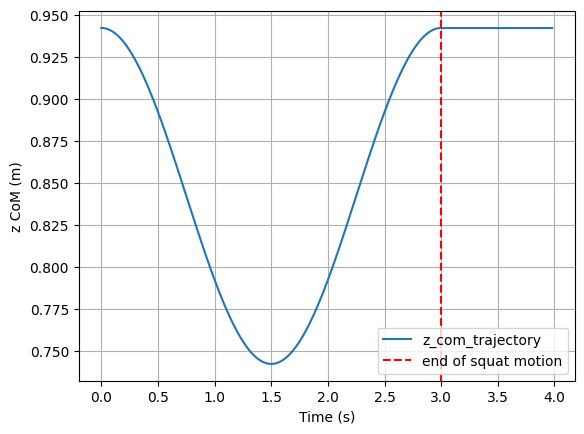

In [5]:
# create trajectory to be used as reference for the CoM
from scripts.build_squat_ocp import *

TRAJECTORY_DURATION = 3.0
HORIZON_LENGTH = 50
OCP_DT = 0.02

reference_com_trajectory = build_squat_com_trajectory(
    model_pinocchio,
    data_pinocchio,
    q0_pin,
    v0,
    traj_duration=TRAJECTORY_DURATION,
    ocp_dt=OCP_DT,
    horizon_length=HORIZON_LENGTH,
    squat_depth=0.20,
)

# create graph
t_all = np.arange(len(reference_com_trajectory)) * OCP_DT
z_all = reference_com_trajectory[:, 2]

plt.figure()
plt.plot(t_all, z_all, label="z_com_trajectory")
plt.axvline(TRAJECTORY_DURATION, color='r', linestyle='--', label="end of squat motion")
plt.xlabel("Time (s)")
plt.ylabel("z CoM (m)")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
# build OCP
from scripts.build_squat_ocp import *
from mpc_controller.mpc_builder import MPCController
import mujoco

#trajectory = build_com_trajectory()
ocp = build_squat_ocp(x0, model_pinocchio, data_pinocchio, reference_com_trajectory, contact_frame_ids, OCP_DT, HORIZON_LENGTH)

# prepare MPC
mpc = MPCController(
    ocp=ocp,
    x0=x0,
    u0=u0,
    max_iter=10,
    com_ref_traj=reference_com_trajectory,
    verbose=True,
)

print("Pinocchio: nq, nv =", model_pinocchio.nq, model_pinocchio.nv)
print("MuJoCo:     nq, nv, nu =", sim.model.nq, sim.model.nv, sim.model.nu)
print("u0.shape =", u0.shape)


nu_ocp = mpc.ocp.problem.runningModels[0].nu

print("nu_ocp = ", nu_ocp)
print("nu_mj = ", sim.model.nu)

Pinocchio: nq, nv = 34 33
MuJoCo:     nq, nv, nu = 34 33 27
u0.shape = (27,)
nu_ocp =  27
nu_mj =  27


In [7]:
PHYSICS_DT = sim.model.opt.timestep   # MuJoCo physics
RATIO_PHYSICS_PER_OCP = int(OCP_DT / PHYSICS_DT)
assert OCP_DT % PHYSICS_DT == 0, "OCP_DT has to be a multiple of PHYSICS_DT"
N_OCP_STEPS = int(TRAJECTORY_DURATION / OCP_DT)


print(f"PHYSICS_DT={PHYSICS_DT}, CONTROL_DT={OCP_DT}, RATIO_PHYSICS_CONTROL={RATIO_PHYSICS_PER_OCP}, N_OCP_STEPS={N_OCP_STEPS}")

ocp_save = []
physics_log = []

with sim.sim_lock:
    q0_mj = sim.data.qpos.copy()
    v0_mj = sim.data.qvel.copy()

q0_pin = mujoco_to_pin_q(q0_mj)
x_current = np.concatenate([q0_pin, v0_mj])
physics_log.append(x_current.copy())

for k in range(N_OCP_STEPS):

    # read input from mujoco
    with sim.sim_lock:
        q_mj = sim.data.qpos.copy()   # (34,)
        v_mj = sim.data.qvel.copy()   # (33,)

    # convertion to pinocchio
    q_pin = mujoco_to_pin_q(q_mj)
    x_meas = np.concatenate([q_pin, v_mj])  # (67,)
    
    # MPC step
    dt_mpc, u_optimal = mpc.step(x_meas)

    # --- LOGS ---

    solver  = mpc.ocp.solver
    problem = mpc.ocp.problem

    running_costs = []
    for t in range(HORIZON_LENGTH):
        model_t = problem.runningModels[t]
        data_t  = problem.runningDatas[t]
        x_t     = solver.xs[t]
        u_t     = solver.us[t]

        model_t.calc(data_t, x_t, u_t)
        running_costs.append(float(data_t.cost))

    terminal_model = problem.terminalModel
    terminal_data  = problem.terminalData
    x_T            = solver.xs[-1]

    terminal_model.calc(terminal_data, x_T)
    terminal_cost = float(terminal_data.cost)

    J_running     = float(np.sum(running_costs))

    current_com_ref = []
    T = len(reference_com_trajectory)
    for j in range(HORIZON_LENGTH):
        idx = k + j
        if idx >= T:
            idx = T - 1
        current_com_ref.append(reference_com_trajectory[idx].copy())

    ocp_snapshot = {
        "iteration": k,
        "converged": solver.stop,
        "solver_iterations": solver.iter,
        "cost_total_solver": float(solver.cost),
        "cost_running_sum": J_running,
        "cost_terminal": terminal_cost,
        "running_costs_per_stage": running_costs,
        "initial_state": x_meas.copy(),
        "xs": [x.copy() for x in solver.xs],
        "us": [u.copy() for u in solver.us],
        "com_reference": current_com_ref,
    }
    ocp_save.append(ocp_snapshot)

    # --- end of LOGS ---

    assert np.isclose(dt_mpc, OCP_DT)

    for _ in range(RATIO_PHYSICS_PER_OCP):
        sim.sim_step(PHYSICS_DT, torques=u_optimal)

        # log
        with sim.sim_lock:
            q_mj = sim.data.qpos.copy()
            v_mj = sim.data.qvel.copy()
        q_pin = mujoco_to_pin_q(q_mj)
        x_current = np.concatenate([q_pin, v_mj])
        physics_log.append(x_current.copy())


PHYSICS_DT=0.002, CONTROL_DT=0.02, RATIO_PHYSICS_CONTROL=10, N_OCP_STEPS=150


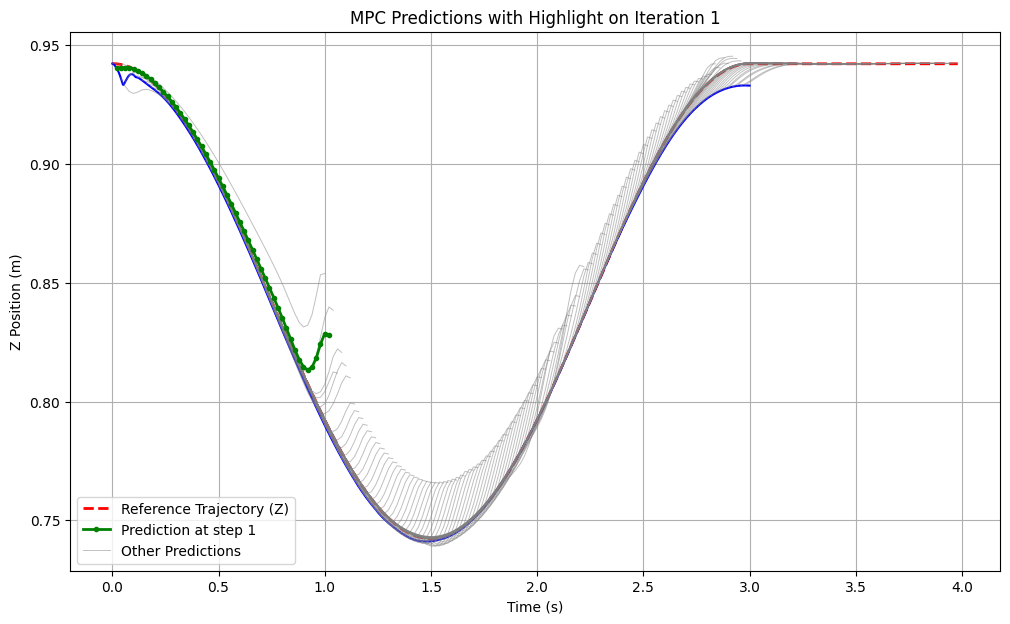

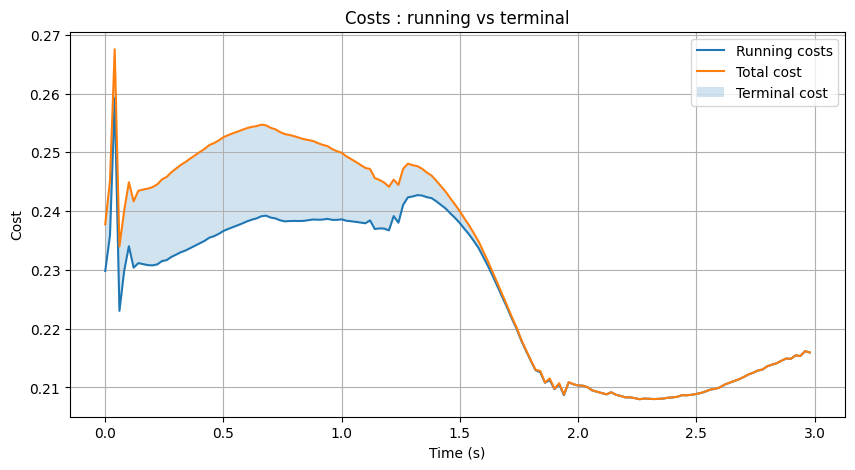

In [8]:
# ==============================================================================
#  Choose an iteration to highlight
# ==============================================================================
ITERATION_TO_HIGHLIGHT = 1
# ==============================================================================

if 'ocp_save' not in locals() or not ocp_save:
    print("'ocp_save' is empty.")

elif ITERATION_TO_HIGHLIGHT >= len(ocp_save):
    print(f"Error : iteration {ITERATION_TO_HIGHLIGHT} is out of range.")

else:
    data_temp = model_pinocchio.createData()

    # Reference trajectory
    z_reference = [com[2] for com in reference_com_trajectory]
    time_axis_reference = np.arange(len(z_reference)) * OCP_DT

    # high frequency trajectory computed by simulator loop
    z_executed_hf = None
    time_axis_executed_hf = None


    data_temp_physics = model_pinocchio.createData()
    z_executed_hf = []

    for x_state in physics_log:
        q = x_state[:model_pinocchio.nq]
        pin.centerOfMass(model_pinocchio, data_temp_physics, q)
        z_executed_hf.append(data_temp_physics.com[0][2])

    z_executed_hf = np.array(z_executed_hf)
    time_axis_executed_hf = np.arange(len(z_executed_hf)) * PHYSICS_DT

    T_max_ref = time_axis_reference[-1]
    valid_idx = time_axis_executed_hf <= T_max_ref
    time_axis_executed_hf = time_axis_executed_hf[valid_idx]
    z_executed_hf = z_executed_hf[valid_idx]


    plt.figure(figsize=(12, 7))
    
    plt.plot(time_axis_reference, z_reference, 'r--', linewidth=2,
             label="Reference Trajectory (Z)")

    if z_executed_hf is not None:
        plt.plot(time_axis_executed_hf, z_executed_hf,
                 'b-', linewidth=1.5,
                 label="Executed Trajectory (Z, high frequency)")

    for i, snapshot in enumerate(ocp_save):
        # Axe de temps de la prédiction en secondes
        time_axis_prediction = (i + np.arange(len(snapshot['xs']))) * OCP_DT

        z_prediction = []
        for x_pred in snapshot['xs']:
            q_pred = x_pred[:model_pinocchio.nq]
            pin.centerOfMass(model_pinocchio, data_temp, q_pred)
            z_prediction.append(data_temp.com[0][2])

        if i == ITERATION_TO_HIGHLIGHT:
            plt.plot(time_axis_prediction, z_prediction,
                     color='green', linestyle='-', linewidth=2,
                     marker='o', markersize=3,
                     label=f"Prediction at step {i}", zorder=10)
        else:
            label = "Other Predictions" if i == 0 else ""
            plt.plot(time_axis_prediction, z_prediction,
                     color='gray', linestyle='-', linewidth=0.7, alpha=0.5,
                     label=label)

    plt.title(f"MPC Predictions with Highlight on Iteration {ITERATION_TO_HIGHLIGHT}")
    plt.xlabel("Time (s)")
    plt.ylabel("Z Position (m)")
    plt.grid(True)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = []
    legend_order = [
        "Reference Trajectory (Z)",
        "Executed Trajectory (Z, simulation loop)",
        f"Prediction at step {ITERATION_TO_HIGHLIGHT}",
        "Other Predictions",
    ]
    for lbl in legend_order:
        if lbl in labels:
            order.append(labels.index(lbl))

    if order:
        plt.legend([handles[idx] for idx in order],
                   [labels[idx] for idx in order])

    plt.show()

# Extract costs 
time_axis = np.arange(len(ocp_save)) * OCP_DT

total_costs   = [snap["cost_total_solver"] for snap in ocp_save]
running_costs = [snap["cost_running_sum"]   for snap in ocp_save]
terminal_costs = [snap["cost_terminal"]    for snap in ocp_save]


plt.figure(figsize=(10, 5))
plt.plot(time_axis, running_costs, label="Running costs")
plt.plot(time_axis, total_costs, label="Total cost")
plt.fill_between(time_axis, running_costs, total_costs, alpha=0.2, label="Terminal cost")
plt.xlabel("Time (s)")
plt.ylabel("Cost")
plt.title("Costs : running vs terminal")
plt.grid(True)
plt.legend()
plt.show()